In [8]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy


from torch import nn
from model import DNN
from umap import UMAP

from run_sim import Config, run_sim, train_model, create_data
from utils import cosine_similarity, get_r_2, vector_angle
from tqdm import tqdm
from tqdm import tqdm
from utils import alignment_score
import matplotlib as mpl
from functools import reduce



In [9]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [10]:
C = Config()

C.G = 0.8
C.sig_h_2 = 1e-5
# C.gpu_id=1
# C.seed = 1
C.linear_net = True
C.split_actions = True
# C.allow_backwards = True
C.learning_rate = 0.0001
C.L=10
C.print_progress = True
C.length_corridors = [30]*1
# C.input_size = 100
C.max_move = 15
C.hidden_size = sum(C.length_corridors)+2*C.max_move+1 + 10
C.num_epochs *= 1
C.algo_name = 'Adam'
C.loss_fn = nn.CrossEntropyLoss()
C.bias = False
C.egocentric_movement = True
C.lambda_reg = 0
# C.whiten_data = True
# C.fixed_output = False
# C.split_actions = False
# C.allow_backwards = True

# C.min_move = 2
# C.one_hot_actions = True
# C.one_hot_inputs = False

In [ ]:
def get_AB(X, w1, w2, b, n):
    # Step 1: Compute target matrix
    Y = (X @ w1) @ w2 + np.ones((X.shape[0], 1)) @ b  # (m, c)

    # Step 2: Compute effective Z = X^\dagger Y
    X_dagger = np.linalg.pinv(X)                     # (d, m)
    Z = X_dagger @ Y                                 # (d, c)

    # Step 3: Low-rank SVD factorization
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    n_max = min(n, min(Z.shape))  # Don't take more components than available
    U_n = np.zeros((U.shape[0], n))  # Initialize with zeros
    S_n = np.zeros((n, n))  # Initialize diagonal matrix with zeros
    Vn = np.zeros((n, Vt.shape[1]))  # Initialize with zeros
    
    # Fill available components
    U_n[:, :n_max] = U[:, :n_max]
    S_n[:n_max, :n_max] = np.diag(np.sqrt(S[:n_max]))
    Vn[:n_max, :] = Vt[:n_max, :]

    A = U_n @ S_n                  # (d, n)
    B = S_n @ Vn                   # (n, c)
    return A, B

def get_tailored_solution(X_np, y_np, C):
    L = C.length_corridors[0]
    L_start = -L/2; L_end = L/2
    A = C.max_move
    n_model = 1
    Win = np.concatenate([np.linspace(L_start,L_end, L), np.linspace(-A,A, 2*A+1)])[:,None]
    Wout = 1/n_model*np.linspace(L_start,L_end, L)[None,:]**n_model
    b = -1/(n_model+1)*np.linspace(L_start,L_end, L)[None, :]**(n_model+1)
    A,B = get_AB(X_np, Win, Wout, b, C.hidden_size)
    W_synthetic = (A@B).T
    return W_synthetic

In [15]:

device = torch.device(f"cuda:{C.gpu_id}" if torch.cuda.is_available() and use_gpu else "cpu")
torch.manual_seed(C.seed)
np.random.seed(C.seed)
loss_thresh = 0.05 if not C.one_hot_inputs else 0.01
X, y, corridor, loc_X, loc_y, action_taken, dim_l, input_size, output_size, n_actions = create_data(C)

X = torch.tensor(X, dtype=torch.float32).to(device)
y = torch.tensor(y, dtype=torch.float32).to(device)

X_np = X.cpu().numpy()  # Convert to numpy array if X is a torch tensor
y_np = y.cpu().numpy()  # Convert to numpy array if y is a torch tensor

if C.sig_h_2 and C.print_progress:
    C.G = (C.sig_h_2*(X.shape[1]+C.hidden_size)/(2*X.shape[1]*X.var()))**(1/(2*C.L))
    print(f'Changed G to {C.G} to get sig_h_2 = {C.sig_h_2}')

# Create model
model = DNN(input_size + n_actions, C.hidden_size, output_size, C.L, C.fixed_output, C.linear_net, C.G, C.bias).to(device)
initial_weights = deepcopy(model.state_dict())

W_dict = {
    'W_synthetic':W_synthetic,
    'W_logistic':LogisticRegression(multi_class='multinomial', fit_intercept=False, tol=1e-12).fit(X_np, y_np.argmax(1)).coef_,
    'W_logistic_noreg':LogisticRegression(multi_class='multinomial', penalty=None, fit_intercept=False, tol=1e-12).fit(X_np, y_np.argmax(1)).coef_,
    'W_correlation':Sigma31@np.linalg.pinv(Sigma11),
}

loss_l, accuracy_l, hidden_l = train_model(C, X, y, model)
# Testing
with torch.no_grad():
    outputs, hidden_states = model(X)
# print(criterion(outputs, y).item()/y_var)

Changed G to 0.6708865165710449 to get sig_h_2 = 1e-05
Accuracy of tailored solution:  0.981159420289855


NameError: name 'get_AB' is not defined

In [12]:


X, y, corridor, loc_X, loc_y, action_taken, hidden_states, loss_l, accuracy_l, outputs, hidden_l, final_weights, initial_weights = run_sim(C)

print(calc_h_var(C.G, X.shape[1], C.hidden_size, C.L, X.var().cpu().numpy()))
hidden = hidden_states[-1].detach().cpu().numpy()
X_dist = torch.cdist(X, X).cpu().numpy()
y_dist = torch.cdist(y, y).cpu().numpy()
hidden_dist = torch.cdist(hidden_states[-1].detach(), hidden_states[-1].detach()).cpu().numpy()
stay_inds = np.where(action_taken == 0)[0]
loc_y_corridor = loc_y + (corridor * max(loc_y + 1))
n_corridors = len(C.length_corridors)

X_np = X.cpu().numpy()  # Convert to numpy array if X is a torch tensor
y_np = y.cpu().numpy()  # Convert to numpy array if y is a torch tensor
h_np = hidden  # Convert to numpy array if hidden is a torch tensor

Changed G to 0.6708865165710449 to get sig_h_2 = 1e-05
Sig_2 of last hidden: 9.892703928926494e-06


100%|██████████| 10000/10000 [00:49<00:00, 203.36it/s]

tensor(1.0000e-05)


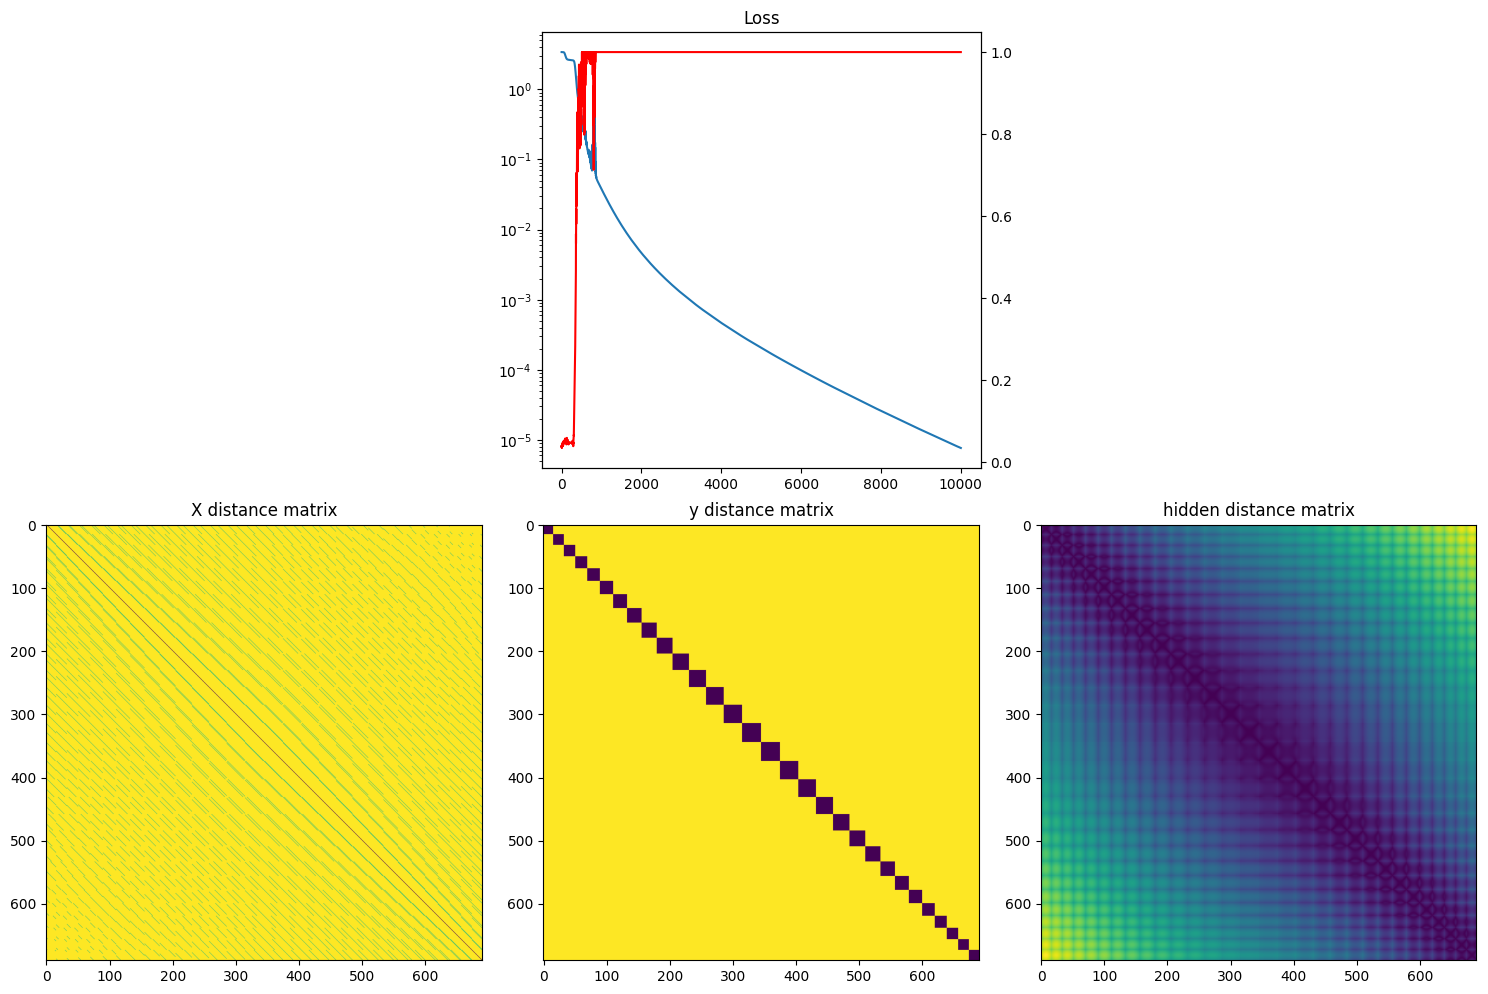

In [13]:
indices = np.lexsort((loc_y, corridor))
# indices = indices[action_taken[indices]==0]
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0,0].set_axis_off(); axs[0,2].set_axis_off()
axs[0,1].plot(loss_l)
axs[0,1].set_yscale('log')
axs[0,1].twinx().plot(accuracy_l, 'r')
axs[0,1].set_title("Loss")
for var, var_name, ax in zip([X_dist, y_dist, hidden_dist], ['X', 'y', 'hidden'], axs[1]):
    ax.imshow(var[indices][:, indices], cmap='viridis')
    ax.set_title(f'{var_name} distance matrix')
    ax.grid(False)
plt.tight_layout()
plt.show()

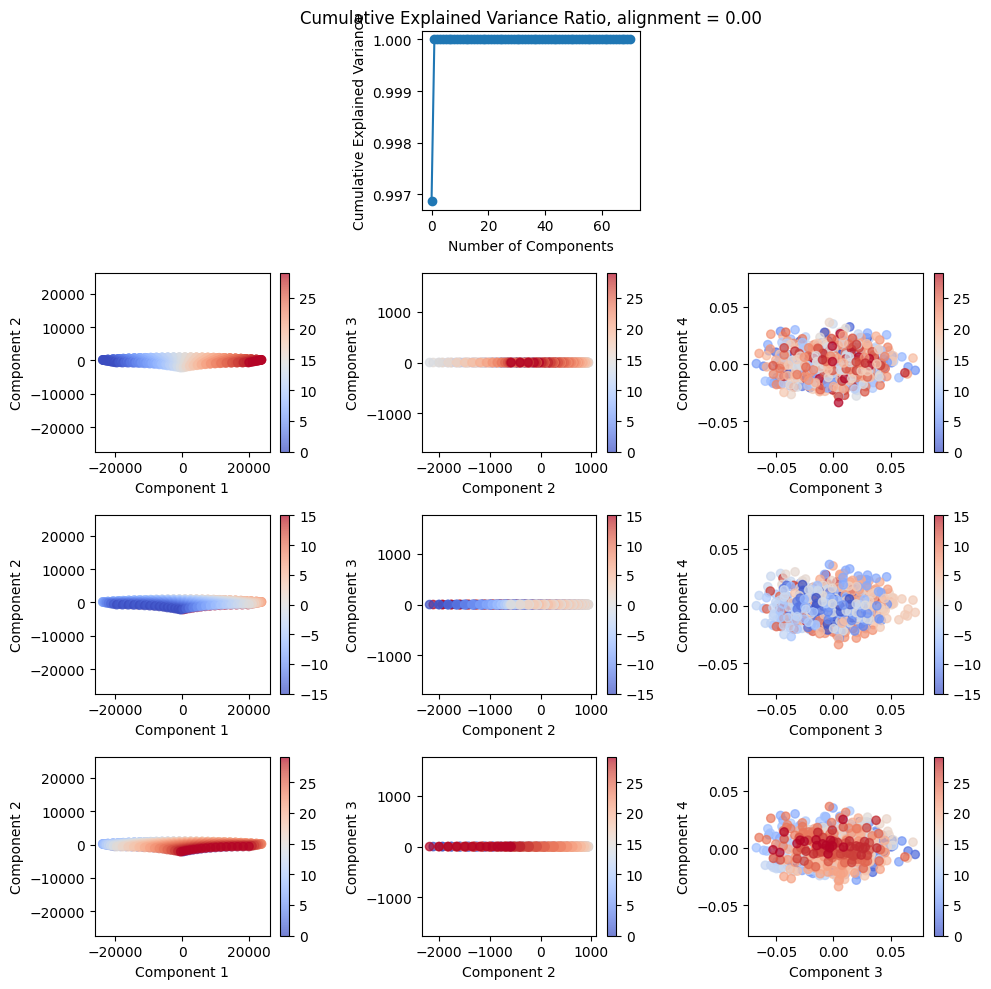

In [14]:
pca = PCA().fit(h_np)
# pca_corridors = [PCA() for i in range(n_corridors)]
# [p.fit(hidden[corridor==i]) for i, p in enumerate(pca_corridors)]
# alignment = np.mean([[cosine_similarity(pca_corridors[i].components_[0], pca_corridors[j].components_[0]) for j in
#                       range(n_corridors) if j!=i] for i in range(n_corridors)])
alignment = alignment_score(hidden[corridor==0], hidden[corridor==1]) if n_corridors > 1 else 0
X_reduced = pca.transform(h_np)
fig = plt.figure(figsize=(10, 10))

markers = list(mpl.markers.MarkerStyle.markers.keys())[2:]
# Add cumulative explained variance ratio in the first row
ax1 = fig.add_subplot(4, 3, 2)
ax1.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Explained Variance')
ax1.set_title(f'Cumulative Explained Variance Ratio, alignment = {alignment:.2f}')

# Add scatter plots in the second row
for i in range(3):
    for j, c in enumerate([loc_y, action_taken, loc_X]):
        ax = fig.add_subplot(4, 3, i + 4 + j*3)
        # c = loc_y
        # c = action_taken[inds]
        for n in range(n_corridors):
            s = ax.scatter(X_reduced[corridor==n, i], X_reduced[corridor==n, i+1], c=c[corridor==n], cmap='coolwarm', alpha=0.7, marker=markers[n])
        ax.set_xlabel(f'Component {i+1}')
        ax.set_ylabel(f'Component {i+2}'),
        ax.axis('equal')
        fig.colorbar(s, ax=ax)

plt.tight_layout()
plt.show()